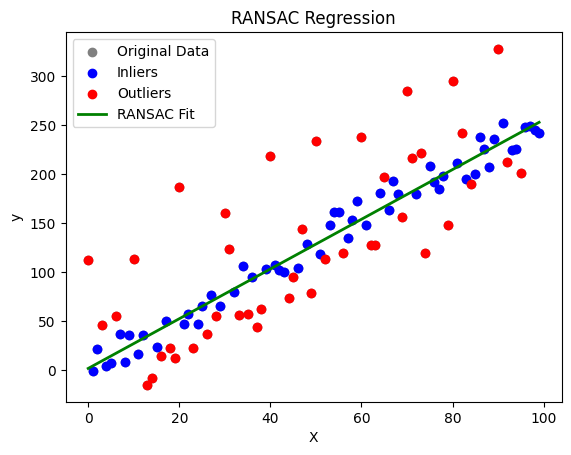

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression


np.random.seed(42)
X = np.arange(100).reshape(-1, 1)
y = 2.5 * X.squeeze() + np.random.normal(0, 25, size=X.shape[0])

y[::10] += 100


ransac = RANSACRegressor(LinearRegression(), max_trials=100, min_samples=50, residual_threshold=20)
ransac.fit(X, y)


line_X = np.arange(100).reshape(-1, 1)
line_y_ransac = ransac.predict(line_X)


plt.scatter(X, y, color='gray', marker='o', label='Original Data')
plt.scatter(X[ransac.inlier_mask_], y[ransac.inlier_mask_], color='blue', label='Inliers')
plt.scatter(X[~ransac.inlier_mask_], y[~ransac.inlier_mask_], color='red', label='Outliers')
plt.plot(line_X, line_y_ransac, color='green', linewidth=2, label='RANSAC Fit')
plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("RANSAC Regression")
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images loaded successfully.
Homography Matrix:
 [[-2.65784798e+00 -3.43319022e-01  3.45738581e+02]
 [-1.18993481e+00 -1.90670274e+00  2.23048722e+02]
 [-1.03945118e-02 -4.14479694e-03  1.00000000e+00]]


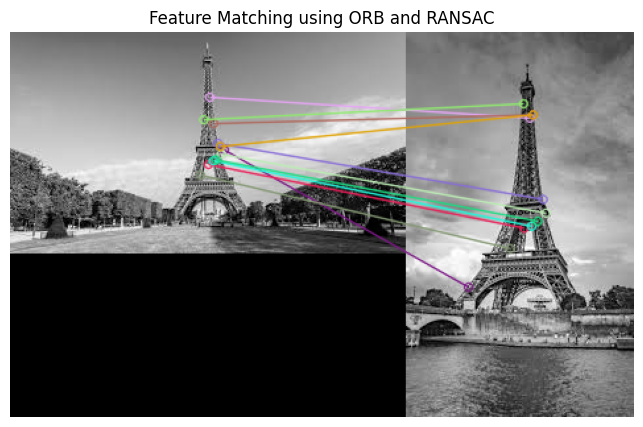

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')


img1_path = "/content/drive/My Drive/image 1.jpeg"
img2_path = "/content/drive/My Drive/image 2.jpeg"


img1 = cv2.imread(img1_path, 0)
img2 = cv2.imread(img2_path, 0)


if img1 is None or img2 is None:
    print("Error: Could not load one or both images.")
else:
    print("Images loaded successfully.")

    orb = cv2.ORB_create(nfeatures=5000)
    keypoints1, descriptors1 = orb.detectAndCompute(img1, None)
    keypoints2, descriptors2 = orb.detectAndCompute(img2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

    if len(good_matches) >= 4:
        pts1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        pts2 = np.float32([keypoints2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
        print("Homography Matrix:\n", H)
    else:
        print("Not enough matching points for homography.")
        H, mask = None, None

    matched_img = cv2.drawMatches(img1, keypoints1, img2, keypoints2, good_matches[:50], None, flags=2)


    plt.figure(figsize=(10, 5))
    plt.imshow(matched_img, cmap='gray')
    plt.title("Feature Matching using ORB and RANSAC")
    plt.axis("off")
    plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


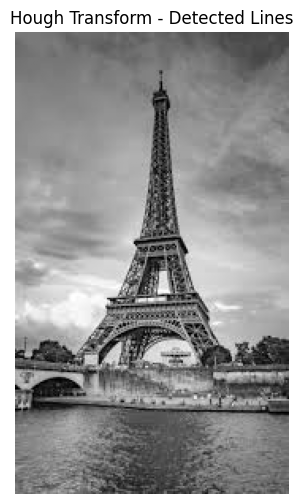

In [ ]:
#Hough
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Mount Google Drive
drive.mount('/content/drive')

# Define image paths in Google Drive
img_path = "/content/drive/My Drive/image 2.jpeg"

img = cv2.imread(img_path, 0)  # Load as grayscale

# Apply Canny edge detection
edges = cv2.Canny(img, 50, 150, apertureSize=3)

# Apply Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

# Draw the detected lines on the image
if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img, (x1, y1), (x2, y2), (255, 255, 255), 2)

# Display the image with detected lines
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')
plt.title("Hough Transform - Detected Lines")
plt.axis("off")
plt.show()
